Общ брой изделия:  100
Лоши изделия:  15
Големината на извадката:  5


----------------------------------------------------------------------------------------------------------------
Шансове за лоши изделия при 5 изтегляния от 100 Общ брой изделия (15 Общ брой лоши изделия):

Общ брой изделия N:100 - Общ брой лоши изделия K:15 - Големината на извадката n:5

#01 -- 0 лоши изделия: 43.56833244075512 %
#02 -- 1 лоши изделия: 40.34104855625474 %
#03 -- 2 лоши изделия: 13.774992189940644 %
#04 -- 3 лоши изделия: 2.157528897219619 %
#05 -- 4 лоши изделия: 0.1541092069442585 %
#06 -- 5 лоши изделия: 0.003988708885616102 %
----------------------------------------------------------------------------------------------------------------

Статистически характеристики:
Средна стойност (μ): 0.75
Дисперсия (σ²): 0.6117424242424242
Стандартно отклонение (σ): 0.7821396449755147
----------------------------------------------------------------------------------------------------------------

Сортирани вероятности (най-вероятни първо):
#01 -- 0 лоши изделия: 43.568332440755

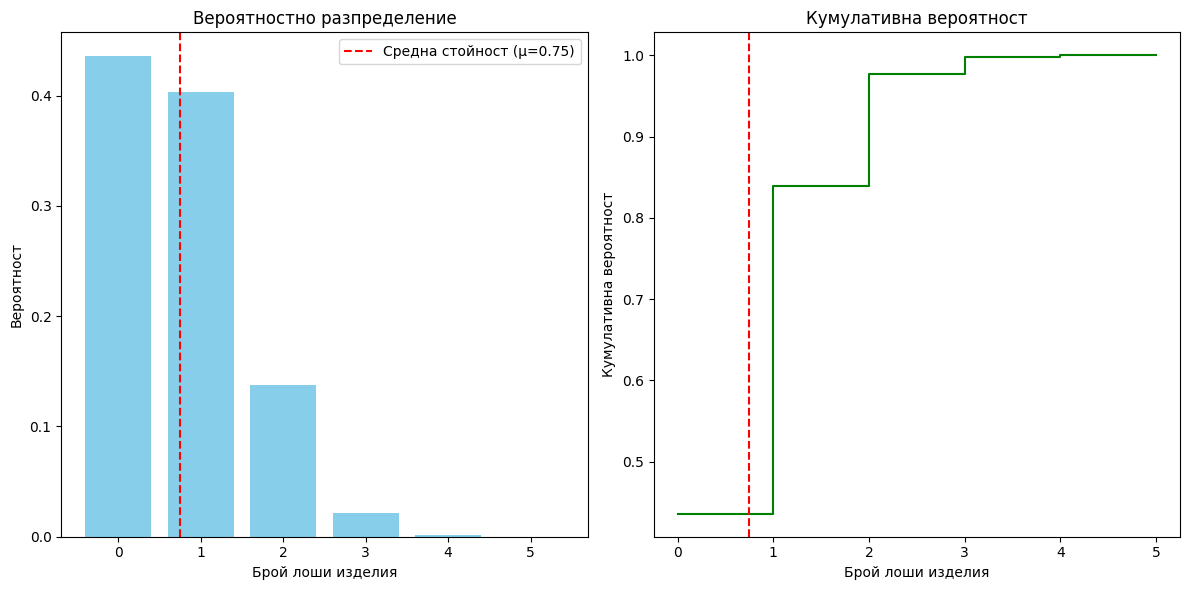

In [1]:
from math import comb, sqrt
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np

# Input parameters
N = int(input("Общ брой изделия: "))
K = int(input("Лоши изделия: "))
n = int(input("Големината на извадката: "))

if K > N or n > N or any(x < 0 for x in [N, K, n]):
    print("Грешка: Невалидни входни данни")
    exit()

d = defaultdict(float)
print("-" * 112)
print(f"Шансове за лоши изделия при {n:_} изтегляния от {N:_} Общ брой изделия ({K:_} Общ брой лоши изделия):\n")
print(f"Общ брой изделия N:{N:_} - Общ брой лоши изделия K:{K:_} - Големината на извадката n:{n:_}")
print()

# Calculate probabilities
counter = 0
for k in range(min(K, n) + 1):
    counter += 1
    prob = (comb(K, k) * comb(N - K, n - k)) / comb(N, n)
    print(f"#{counter:02} -- {k} лоши изделия: {prob * 100} %")
    d[k] = prob

print("-" * 112)

# Calculate statistics
mean = sum(k * prob for k, prob in d.items())
variance = sum((k - mean)**2 * prob for k, prob in d.items())
std_dev = sqrt(variance)

print("\nСтатистически характеристики:")
print(f"Средна стойност (μ): {mean}")
print(f"Дисперсия (σ²): {variance}")
print(f"Стандартно отклонение (σ): {std_dev}")
print("-" * 112)

# Sort and print probabilities
sorted_d = dict(sorted(d.items(), key=lambda kvp: (-kvp[1], kvp[0])))

counter_1 = 0
print("\nСортирани вероятности (най-вероятни първо):")
for key, value in sorted_d.items():
    counter_1 += 1
    print(f"#{counter_1:02} -- {key} лоши изделия: {value * 100} %")
print("-" * 112)

# Visualization
plt.figure(figsize=(12, 6))

# Probability distribution plot
plt.subplot(1, 2, 1)
plt.bar(d.keys(), d.values(), color='skyblue')
plt.title('Вероятностно разпределение')
plt.xlabel('Брой лоши изделия')
plt.ylabel('Вероятност')
plt.axvline(mean, color='red', linestyle='--', label=f'Средна стойност (μ={mean:.2f})')
plt.legend()

# Cumulative probability plot
plt.subplot(1, 2, 2)
cumulative_probs = np.cumsum(list(d.values()))
plt.step(list(d.keys()), cumulative_probs, where='post', color='green')
plt.title('Кумулативна вероятност')
plt.xlabel('Брой лоши изделия')
plt.ylabel('Кумулативна вероятност')
plt.axvline(mean, color='red', linestyle='--')

plt.tight_layout()
plt.show()